# Data Visualization
This notebook includes plots to include in the report

In [1]:
import pandas as pd
from src.config import get_config
from src.data_loader import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

config = get_config()

The below cell takes some time to run as it loads a bunch of data

In [2]:
loader = DataLoader(data_path = "../data")

# Get option data from
query = (
    f"SELECT {', '.join(config.relevant_option_columns)} FROM options_enriched"
    f" WHERE date >= '{config.start_date}' AND date <= '{config.end_date}'"
    f" AND tte_days <= {config.max_tte}"
)
df = loader.query(query)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

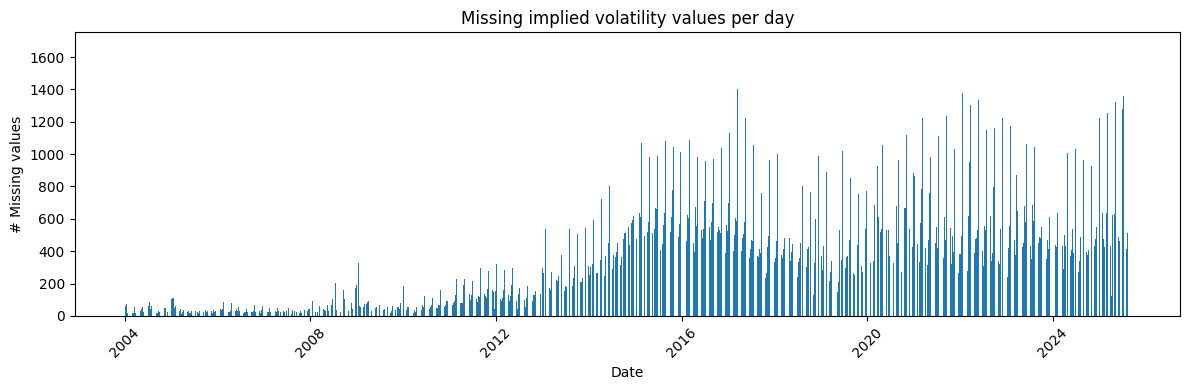

In [14]:
# nan_visualizing = df.loc[df['impl_volatility'].isna(), ['date', 'impl_volatility']].groupby(by='date').transform('count')
nan_per_day = df[df['impl_volatility'].isna()].groupby('date')['impl_volatility'].size()
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(nan_per_day.index, nan_per_day.values)
ax.set_xlabel("Date")
ax.set_ylabel("# Missing values")
ax.set_title("Missing implied volatility values per day")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../plots/data_visualization/missing_values_per_day.png')
plt.show()

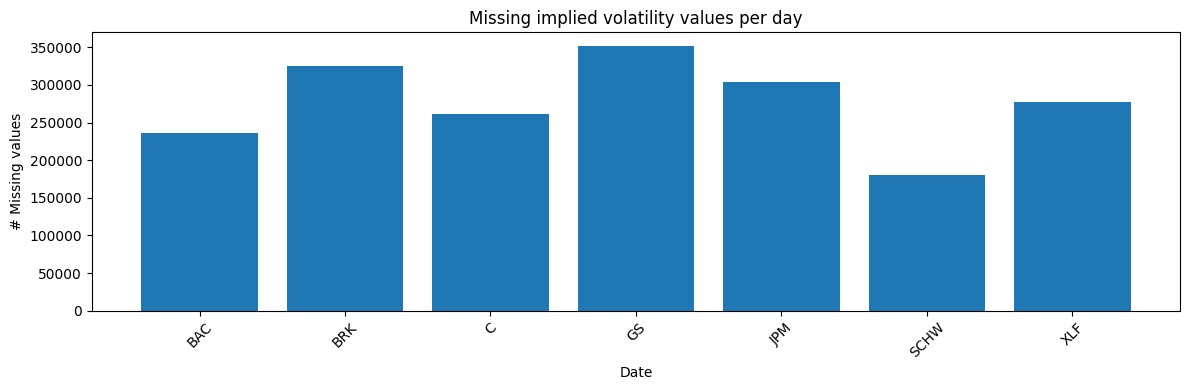

In [13]:
nan_per_day = df[df['impl_volatility'].isna()].groupby('ticker')['impl_volatility'].size()
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(nan_per_day.index, nan_per_day.values)
ax.set_xlabel("Date")
ax.set_ylabel("# Missing values")
ax.set_title("Missing implied volatility values per day")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../plots/data_visualization/missing_values_per_ticker.png')
plt.show()

In [17]:
df.nlargest(10, 'impl_volatility')[['date', 'ticker', 'impl_volatility', 'tte_days']]

,date,ticker,impl_volatility,tte_days
4377241,2011-12-22,C,8.998517,1
890057,2013-07-19,XLF,8.998424,1
78294,2017-01-19,C,8.996746,1
2529593,2021-01-14,JPM,8.995357,1
5360777,2012-04-10,BAC,8.995154,11
3383266,2004-01-16,SCHW,8.995151,1
3027548,2017-06-05,XLF,8.994975,11
3148553,2016-08-24,BAC,8.994681,2
3400866,2007-10-19,SCHW,8.993869,1
5364212,2012-06-18,BAC,8.992830,4
